## Imports, configuration, GPU / mixed precision

In [2]:
pip install mlxtend

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.4 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 192.5 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.4/308.4 KB 110.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import math
import warnings

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from mlxtend.plotting import plot_decision_regions

warnings.filterwarnings('ignore')

from IPython.core.interactiveshell import InteractiveShell
from IPython.display import display, HTML

InteractiveShell.ast_node_interactivity = "all"
display(HTML("<style>.output_scroll {height:auto !important; max-height:none !important;}</style>"))


SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# GPU configuration
print("=" * 60)
print("GPU CONFIGURATION")
print("=" * 60)
gpus = tf.config.list_physical_devices('GPU')
USE_GPU = bool(gpus)
if USE_GPU:
    print(f"GPUs available: {len(gpus)}")
    for gpu in gpus:
        print("  -", gpu)
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled")
    except RuntimeError as e:
        print(e)
else:
    print("No GPUs available, using CPU")


policy_name = 'mixed_float16' if USE_GPU else 'float32'
tf.keras.mixed_precision.set_global_policy(policy_name)
print(f"Mixed precision policy: {tf.keras.mixed_precision.global_policy().name}")
print("=" * 60 + "\n")


USE_XLA = USE_GPU


2025-12-02 00:44:50.771029: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764636290.780174    6704 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764636290.784560    6704 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1764636290.789856    6704 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1764636290.789871    6704 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1764636290.789872    6704 computation_placer.cc:177] computation placer alr

GPU CONFIGURATION
GPUs available: 1
  - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
GPU memory growth enabled
Mixed precision policy: mixed_float16



## LASA activation (adaptive sine + angle window + optional gain cap)

In [2]:

class LASAActivation(tf.keras.layers.Layer):
    """
    Layer-wise Adaptive Sine Activation (LASA).

    h(x) = sin(tau * (Wx + b)), with:
      - tau trainable via rho (softplus or bounded sigmoid),
      - optional gain cap via tau_max,
      - angle-window penalty on |cos(phi)| to control layer gain.
    """
    def __init__(self, theta_degrees=45.0, lambda_window=3e-4,
                 penalty_mode='hinge', hybrid_alpha=0.1,
                 enforce_gain_cap=False, gain_cap=1.25,
                 initial_frequency=1.6, name=None, **kwargs):
        super().__init__(name=name, **kwargs)
        self.theta_degrees     = float(theta_degrees)
        self.lambda_window     = float(lambda_window)
        self.penalty_mode      = str(penalty_mode)
        self.hybrid_alpha      = float(hybrid_alpha)
        self.enforce_gain_cap  = bool(enforce_gain_cap)
        self.gain_cap          = float(gain_cap)
        self.initial_frequency = float(initial_frequency)

    def build(self, input_shape):
        # Angle window centre around ±pi/2, half-width theta
        self.theta_rad = tf.constant(self.theta_degrees * math.pi / 180.0, dtype=tf.float32)
        self.sin_theta = tf.sin(self.theta_rad)

        # Scale to warm up the window penalty
        self.penalty_scale = self.add_weight(
            shape=(), name='penalty_scale', dtype=tf.float32, trainable=False,
            initializer=tf.keras.initializers.Constant(1.0)
        )

        # Reparameterise tau via rho, with optional gain cap
        if self.enforce_gain_cap:
            denom   = tf.maximum(self.sin_theta, tf.constant(1e-6, tf.float32))
            k_max_v = float(self.gain_cap) / float(denom.numpy())  # tau_max
            self.k_max = tf.constant(k_max_v, dtype=tf.float32)
            ratio = np.clip(self.initial_frequency / k_max_v, 1e-6, 1.0 - 1e-6)
            rho0  = np.log(ratio / (1.0 - ratio))
        else:
            self.k_max = None
            rho0 = inv_softplus(self.initial_frequency)

        self.rho = self.add_weight(
            shape=(), name='rho', dtype=tf.float32, trainable=True,
            initializer=tf.keras.initializers.Constant(float(rho0))
        )

    @property
    def tau_value(self):
        """Current frequency tau derived from rho."""
        if self.enforce_gain_cap:
            return self.k_max * tf.nn.sigmoid(self.rho)
        return tf.nn.softplus(self.rho)

    def set_penalty_scale(self, scale):
        self.penalty_scale.assign(tf.cast(scale, tf.float32))

    def scale_down_penalty(self, factor=0.8, min_scale=0.05):
        new_scale = tf.maximum(self.penalty_scale * tf.cast(factor, tf.float32),
                               tf.constant(min_scale, tf.float32))
        self.penalty_scale.assign(new_scale)

    def _penalty(self, inputs, tau32):
        """Angle-window penalty on |cos(phi)|."""
        if self.lambda_window <= 0.0:
            return None

        x32     = tf.cast(inputs, tf.float32)
        cos_phi = tf.math.cos(tau32 * x32)
        abs_cos = tf.abs(cos_phi)

        if self.penalty_mode == 'hinge':
            margin = self.sin_theta
            viol   = tf.maximum(abs_cos - margin, 0.0)
            pen    = tf.reduce_mean(tf.square(viol))
        elif self.penalty_mode == 'cos2':
            pen    = tf.reduce_mean(tf.square(cos_phi))
        elif self.penalty_mode == 'hybrid':
            margin = self.sin_theta
            viol   = tf.maximum(abs_cos - margin, 0.0)
            hinge  = tf.reduce_mean(tf.square(viol))
            cos2   = tf.reduce_mean(tf.square(cos_phi))
            pen    = self.hybrid_alpha * cos2 + hinge
        else:
            raise ValueError("penalty_mode must be 'hinge', 'cos2', or 'hybrid'.")

        lw32    = tf.cast(self.lambda_window, tf.float32)
        scale32 = tf.cast(self.penalty_scale, tf.float32)
        return lw32 * scale32 * pen

    def call(self, inputs):
        tau32 = tf.cast(self.tau_value, tf.float32)
        pen = self._penalty(inputs, tau32)
        if pen is not None:
            self.add_loss(pen)

        x32 = tf.cast(inputs, tf.float32)
        y32 = tf.math.sin(tau32 * x32)
        return tf.cast(y32, inputs.dtype)


## LASA-only model builder

In [3]:
def create_lasa_model(hidden_units=[16],
                      initial_frequency=2.0,
                      theta_degrees=45.0, lambda_window=3e-4,
                      penalty_mode='hinge', hybrid_alpha=0.1,
                      enforce_gain_cap=False, gain_cap=1.25):
    """Create a single-hidden-layer LASA network for 2D inputs."""
    with tf.device('/GPU:0' if USE_GPU else '/CPU:0'):
        model = tf.keras.Sequential([tf.keras.layers.Input(shape=(2,))])
        for i, units in enumerate(hidden_units):
            model.add(tf.keras.layers.Dense(units, name=f'dense_{i}'))
            model.add(LASAActivation(
                theta_degrees=theta_degrees,
                lambda_window=lambda_window,
                penalty_mode=penalty_mode, hybrid_alpha=hybrid_alpha,
                enforce_gain_cap=enforce_gain_cap, gain_cap=gain_cap,
                initial_frequency=initial_frequency,
                name=f'lasa_{i}'
            ))
        # Binary output; keep output in float32 for numerical stability
        model.add(tf.keras.layers.Dense(1, activation='sigmoid', dtype='float32', name='output'))
    return model


## LASA Trainer

In [4]:


class LASATrainer:
    def __init__(self, model,
                 lr_main=1e-3, lr_tau=1e-2,
                 clipnorm_main=1.0, clipnorm_tau=0.5,
                 penalty_warmup_epochs=8,
                 acc_eps=2.5e-3, loss_eps=1e-4,
                 reverse_tau_grads=True, revert_rho_to_snapshot=True,
                 shrink_tau_lr=True, tau_lr_decay=0.5, min_tau_lr=1e-5,
                 shrink_penalty=True, penalty_decay=0.8, min_penalty_scale=0.05,
                 stagnation_window=10, improve_threshold=0.05,
                 bump_delta_k=1.0, min_epochs_between_bumps=10,
                 acc_drop_threshold=0.02):
        self.model = model
        self.loss_fn = tf.keras.losses.BinaryCrossentropy()
        self.optimizer_main = tf.keras.optimizers.Adam(learning_rate=lr_main, clipnorm=clipnorm_main)
        self.optimizer_tau  = tf.keras.optimizers.Adam(learning_rate=lr_tau,  clipnorm=clipnorm_tau)
        self.penalty_warmup_epochs = int(penalty_warmup_epochs)

        self.acc_eps = float(acc_eps)
        self.loss_eps = float(loss_eps)
        self.reverse_tau_grads = bool(reverse_tau_grads)
        self.revert_rho_to_snapshot = bool(revert_rho_to_snapshot)
        self.shrink_tau_lr = bool(shrink_tau_lr)
        self.tau_lr_decay = float(tau_lr_decay)
        self.min_tau_lr = float(min_tau_lr)
        self.shrink_penalty = bool(shrink_penalty)
        self.penalty_decay = float(penalty_decay)
        self.min_penalty_scale = float(min_penalty_scale)

        self.stagnation_window = int(stagnation_window)
        self.improve_threshold = float(improve_threshold)
        self.bump_delta_k = float(bump_delta_k)
        self.min_epochs_between_bumps = int(min_epochs_between_bumps)

        self.acc_drop_threshold = float(acc_drop_threshold)

        self._partition_ready = False
        self.tau_idx, self.other_idx = [], []
        self._best_val_acc  = -np.inf
        self._best_val_loss =  np.inf
        self.val_acc_hist   = []
        self._last_bump_epoch = -10**9
        self.tau_grad_dir = tf.Variable(1.0, trainable=False, dtype=tf.float32)

        self.pending_bump = False
        self.bump_pre_val_acc = None
        self.rho_bump_snapshot = None
        self.bump_reverted_once = False
        self.final_bump_to_apply = False
        self.final_bump_applied = False
        self.disable_future_bumps = False
        self.no_revert_mode = False

    def _build_and_partition(self, sample_x):
        # Force variable creation
        _ = self.model(sample_x)
        self.tau_idx, self.other_idx = [], []
        for i, v in enumerate(self.model.trainable_variables):
            if '/rho:' in v.name:
                self.tau_idx.append(i)
            else:
                self.other_idx.append(i)
        self._partition_ready = True

    def _set_penalty_scale(self, epoch_idx):
        scale = 1.0 if self.penalty_warmup_epochs <= 0 else min(1.0, (epoch_idx + 1) / self.penalty_warmup_epochs)
        for layer in self.model.layers:
            if isinstance(layer, LASAActivation):
                layer.set_penalty_scale(scale)

    def _decay_penalty_scale(self):
        if not self.shrink_penalty:
            return
        for layer in self.model.layers:
            if isinstance(layer, LASAActivation):
                layer.scale_down_penalty(self.penalty_decay, self.min_penalty_scale)

    def _snapshot_rho(self):
        return [self.model.trainable_variables[i].numpy().copy() for i in self.tau_idx]

    def _restore_rho(self, snap):
        for val, i in zip(snap, self.tau_idx):
            self.model.trainable_variables[i].assign(val)

    def _reset_tau_optimizer(self, new_lr):
        self.optimizer_tau = tf.keras.optimizers.Adam(
            learning_rate=new_lr, clipnorm=self.optimizer_tau.clipnorm
        )

    def _bump_all_k(self, delta):
        for layer in self.model.layers:
            if isinstance(layer, LASAActivation):
                k0 = float(layer.tau_value.numpy())
                if layer.enforce_gain_cap:
                    kmax = float(layer.k_max.numpy())
                    k1 = min(kmax * 0.999, k0 + float(delta))
                    ratio = np.clip(k1 / kmax, 1e-6, 1.0 - 1e-6)
                    rho_new = np.log(ratio / (1.0 - ratio))
                else:
                    k1 = max(0.0, k0 + float(delta))
                    rho_new = inv_softplus(k1)
                layer.rho.assign(np.float32(rho_new))

    def _current_k_values(self):
        ks = []
        for layer in self.model.layers:
            if isinstance(layer, LASAActivation):
                ks.append(float(layer.tau_value.numpy()))
        return ks

    @tf.function(jit_compile=USE_XLA)
    def _train_step(self, x_batch, y_batch):
        with tf.GradientTape() as tape:
            preds = self.model(x_batch, training=True)
            yb = tf.reshape(y_batch, (-1, 1))
            main_loss = self.loss_fn(yb, preds)
            reg_losses = tf.add_n(self.model.losses) if self.model.losses else tf.constant(0.0, dtype=main_loss.dtype)
            loss = main_loss + reg_losses
        grads = tape.gradient(loss, self.model.trainable_variables)

        tau_pairs = []
        for i in self.tau_idx:
            g = grads[i]; v = self.model.trainable_variables[i]
            if g is not None:
                g = tf.cast(g, tf.float32) * self.tau_grad_dir
                tau_pairs.append((g, v))
        other_pairs = []
        for i in self.other_idx:
            g = grads[i]; v = self.model.trainable_variables[i]
            if g is not None:
                other_pairs.append((g, v))

        if tau_pairs:
            self.optimizer_tau.apply_gradients(tau_pairs)
        if other_pairs:
            self.optimizer_main.apply_gradients(other_pairs)

        return main_loss

    def _val_metrics(self, X_val, y_val):
        preds = self.model(X_val, training=False)
        yb = tf.reshape(y_val, (-1, 1))
        val_loss = float(self.loss_fn(yb, preds).numpy())
        y_pred = (preds.numpy() > 0.5).astype(int).flatten()
        val_acc = float(np.mean(y_pred == y_val.numpy()))
        return val_loss, val_acc

    def train(self, X_train, y_train, X_val, y_val, epochs=40, batch_size=32, verbose=True):
        X_train = tf.constant(X_train, dtype=tf.float32)
        y_train = tf.constant(y_train, dtype=tf.float32)
        X_val   = tf.constant(X_val,   dtype=tf.float32)
        y_val   = tf.constant(y_val,   dtype=tf.float32)

        if not self._partition_ready:
            self._build_and_partition(X_train[:1])

        ds = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
              .shuffle(4096).batch(batch_size).prefetch(tf.data.AUTOTUNE))

        history = {'loss': [], 'val_accuracy': [], 'val_loss': [], 'k': []}

        for epoch in range(epochs):
            self._set_penalty_scale(epoch)

            if self.final_bump_to_apply and not self.final_bump_applied:
                self._bump_all_k(self.bump_delta_k)
                self.final_bump_applied = True
                self.final_bump_to_apply = False
                self.disable_future_bumps = True
                self.no_revert_mode = True

            rho_snap_epoch = self._snapshot_rho()

            total_loss = 0.0
            nb = 0
            for xb, yb in ds:
                main_l = self._train_step(xb, yb)
                total_loss += float(main_l.numpy())
                nb += 1

            avg_loss = total_loss / max(nb, 1)
            val_loss, val_acc = self._val_metrics(X_val, y_val)

            if self.pending_bump and not self.final_bump_applied:
                if self.bump_pre_val_acc is not None:
                    drop = self.bump_pre_val_acc - val_acc
                    if drop > self.acc_drop_threshold and not self.bump_reverted_once:
                        self._restore_rho(self.rho_bump_snapshot)
                        self.bump_reverted_once = True
                        self.pending_bump = False
                        self.final_bump_to_apply = True
                        val_loss, val_acc = self._val_metrics(X_val, y_val)
                if self.pending_bump:
                    self.pending_bump = False

            worse_acc  = (val_acc  < self._best_val_acc  - self.acc_eps)
            worse_loss = (val_loss > self._best_val_loss + self.loss_eps)
            if (worse_acc or worse_loss):
                if self.revert_rho_to_snapshot and not self.no_revert_mode:
                    self._restore_rho(rho_snap_epoch)
                if self.reverse_tau_grads:
                    self.tau_grad_dir.assign(-self.tau_grad_dir)
                if self.shrink_tau_lr:
                    new_lr = max(self.min_tau_lr,
                                 float(self.optimizer_tau.learning_rate.numpy()) * self.tau_lr_decay)
                    self._reset_tau_optimizer(new_lr)
                if self.shrink_penalty:
                    self._decay_penalty_scale()
                val_loss, val_acc = self._val_metrics(X_val, y_val)

            ep = epoch + 1
            self.val_acc_hist.append(val_acc)
            can_try_bump = (not self.disable_future_bumps) and (not self.final_bump_applied)
            if can_try_bump and ep >= self.stagnation_window and (ep - self._last_bump_epoch) >= self.min_epochs_between_bumps:
                acc_then = self.val_acc_hist[-self.stagnation_window]
                improve  = val_acc - acc_then
                if improve < self.improve_threshold:
                    self.rho_bump_snapshot = self._snapshot_rho()
                    self.bump_pre_val_acc  = val_acc
                    self._bump_all_k(self.bump_delta_k)
                    self.pending_bump = True
                    self._last_bump_epoch = ep

            self._best_val_acc  = max(self._best_val_acc,  val_acc)
            self._best_val_loss = min(self._best_val_loss, val_loss)

            history['k'].append(self._current_k_values())
            history['loss'].append(avg_loss)
            history['val_accuracy'].append(val_acc)
            history['val_loss'].append(val_loss)

            if verbose:
                print(f"Epoch {epoch+1:03d} | loss: {avg_loss:.4f} | val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f}")

        return history


## Plot (decision boundary, training curves, k evolution)

In [5]:
def plot_lasa_decision_boundary(model, X_test, y_test, title_suffix="Complex Checkerboard"):
    class Wrapper:
        def __init__(self, model):
            self.model = model
        def predict(self, X):
            X_tensor = tf.constant(X, dtype=tf.float32)
            preds = self.model(X_tensor)
            return (preds.numpy() > 0.5).astype(int).flatten()

    wrapper = Wrapper(model)
    plt.figure(figsize=(6, 5))
    plot_decision_regions(X=X_test, y=y_test, clf=wrapper, legend=0)
    plt.title(f"LASA decision boundary ({title_suffix})")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_lasa_training_curves(history):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history['loss'], label='train loss')
    plt.plot(history['val_loss'], label='val loss', linestyle='--')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and validation loss")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['val_accuracy'], label='val accuracy')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Validation accuracy")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

def plot_k_evolution(history, title_suffix="Complex Checkerboard"):
    if 'k' not in history or len(history['k']) == 0:
        print("No k history to plot.")
        return

    K = np.array([np.array(ks, dtype=float) for ks in history['k']], dtype=object)
    try:
        K = np.stack(K).astype(float)
    except Exception:
        print("Ragged k history; cannot plot.")
        return

    plt.figure(figsize=(7, 4))
    for j in range(K.shape[1]):
        plt.plot(K[:, j], label=f'k[{j}]')
    plt.title(f"k evolution per LASA layer ({title_suffix})")
    plt.xlabel("Epoch")
    plt.ylabel("k (tau)")
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()


## Utility functions and dataset (complex checkerboard)

In [6]:
def inv_softplus(y):
    """Inverse of softplus used to initialise rho."""
    y = np.maximum(float(y), 1e-6)
    return np.log(np.expm1(y))

def make_complex_checkerboard(n_samples=1500, grid_size=4, noise=0.02):
    """Synthetic 2D complex checkerboard dataset."""
    np.random.seed(SEED)
    
    X = np.random.rand(n_samples, 2) * grid_size

    # Push some samples near the internal grid boundaries to make task harder
    boundary_samples = int(n_samples * 0.3)
    for i in range(boundary_samples):
        if np.random.rand() > 0.5:
            X[i, 0] = np.random.choice(np.arange(1, grid_size)) + np.random.normal(0, 0.1)
        if np.random.rand() > 0.5:
            X[i, 1] = np.random.choice(np.arange(1, grid_size)) + np.random.normal(0, 0.1)
    
    if noise > 0:
        X += np.random.normal(0, noise, X.shape)
    
    X = np.clip(X, 0, grid_size)
    
    y = (np.floor(X[:, 0]) + np.floor(X[:, 1])) % 2
    y = y.astype(int)
    
    return X.astype(np.float32), y.astype(np.int32)


## Single LASA experiment

Dataset: total=1500 | train=1200 | test=300
Class counts: 0 -> 753  | 1 -> 747


I0000 00:00:1764636524.075329    6704 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 93258 MB memory:  -> device: 0, name: NVIDIA GH200 480GB, pci bus id: 0000:dd:00.0, compute capability: 9.0
I0000 00:00:1764636526.319578    6704 service.cc:152] XLA service 0xafd0a15e1bf0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764636526.319612    6704 service.cc:160]   StreamExecutor device (0): NVIDIA GH200 480GB, Compute Capability 9.0
2025-12-02 00:48:46.335774: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1764636526.533489    6704 cuda_dnn.cc:529] Loaded cuDNN version 90800
I0000 00:00:1764636527.005075    6704 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2025-12-02 00:48:47.857164: I tensorflow/core/frame

Epoch 001 | loss: 0.7742 | val_loss: 0.7163 | val_acc: 0.4867
Epoch 002 | loss: 0.7051 | val_loss: 0.7026 | val_acc: 0.4767


2025-12-02 00:48:48.232778: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 003 | loss: 0.6931 | val_loss: 0.6993 | val_acc: 0.5000
Epoch 004 | loss: 0.6875 | val_loss: 0.6986 | val_acc: 0.5133
Epoch 005 | loss: 0.6849 | val_loss: 0.6963 | val_acc: 0.5000


...

Epoch 017 | loss: 0.6656 | val_loss: 0.6787 | val_acc: 0.5233
Epoch 018 | loss: 0.6654 | val_loss: 0.6785 | val_acc: 0.5200
Epoch 019 | loss: 0.6642 | val_loss: 0.6777 | val_acc: 0.5067
Epoch 020 | loss: 0.6631 | val_loss: 0.6769 | val_acc: 0.5200
Epoch 021 | loss: 0.6753 | val_loss: 0.6772 | val_acc: 0.4933
Epoch 022 | loss: 0.6826 | val_loss: 0.6596 | val_acc: 0.5833
Epoch 023 | loss: 0.6441 | val_loss: 0.6342 | val_acc: 0.5967
Epoch 024 | loss: 0.6245 | val_loss: 0.6180 | val_acc: 0.6333
Epoch 025 | loss: 0.6059 | val_loss: 0.6060 | val_acc: 0.6400
Epoch 026 | loss: 0.5952 | val_loss: 0.5990 | val_acc: 0.6567
Epoch 027 | loss: 0.5884 | val_loss: 0.5913 | val_acc: 0.6867
Epoch 028 | loss: 0.5782 | val_loss: 0.5869 | val_acc: 0.6700
Epoch 029 | loss: 0.5745 | val_loss: 0.5764 | val_acc: 0.7033
Epoch 030 | loss: 0.5684 | val_loss: 0.5689 | val_acc: 0.7100
Epoch 031 | loss: 0.5621 | val_loss: 0.5674 | val_acc: 0.7200
Epoch 032 | loss: 0.5602 | val_loss: 0.5635 | val_acc: 0.7200


2025-12-02 00:48:51.211232: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 033 | loss: 0.5542 | val_loss: 0.5605 | val_acc: 0.7133
Epoch 034 | loss: 0.5488 | val_loss: 0.5580 | val_acc: 0.7167
Epoch 035 | loss: 0.5489 | val_loss: 0.5536 | val_acc: 0.7300
Epoch 036 | loss: 0.5435 | val_loss: 0.5537 | val_acc: 0.7267
Epoch 037 | loss: 0.5439 | val_loss: 0.5491 | val_acc: 0.7233
Epoch 038 | loss: 0.5380 | val_loss: 0.5409 | val_acc: 0.7367
Epoch 039 | loss: 0.5359 | val_loss: 0.5448 | val_acc: 0.7433
Epoch 040 | loss: 0.5336 | val_loss: 0.5408 | val_acc: 0.7400
Epoch 041 | loss: 0.5320 | val_loss: 0.5420 | val_acc: 0.7300
Epoch 042 | loss: 0.5318 | val_loss: 0.5356 | val_acc: 0.7433
Epoch 043 | loss: 0.5298 | val_loss: 0.5350 | val_acc: 0.7467
Epoch 044 | loss: 0.5276 | val_loss: 0.5322 | val_acc: 0.7533
Epoch 045 | loss: 0.5257 | val_loss: 0.5363 | val_acc: 0.7400
Epoch 046 | loss: 0.5247 | val_loss: 0.5325 | val_acc: 0.7500
Epoch 047 | loss: 0.5204 | val_loss: 0.5280 | val_acc: 0.7500
Epoch 048 | loss: 0.5206 | val_loss: 0.5338 | val_acc: 0.7367
Epoch 04

2025-12-02 00:48:54.431563: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 065 | loss: 0.5161 | val_loss: 0.5147 | val_acc: 0.7500
Epoch 066 | loss: 0.5099 | val_loss: 0.5171 | val_acc: 0.7533
Epoch 067 | loss: 0.5067 | val_loss: 0.5102 | val_acc: 0.7533
Epoch 068 | loss: 0.5082 | val_loss: 0.5147 | val_acc: 0.7500
Epoch 069 | loss: 0.5092 | val_loss: 0.5152 | val_acc: 0.7567
Epoch 070 | loss: 0.5102 | val_loss: 0.5173 | val_acc: 0.7400
Epoch 071 | loss: 0.5076 | val_loss: 0.5184 | val_acc: 0.7367
Epoch 072 | loss: 0.5037 | val_loss: 0.5122 | val_acc: 0.7500
Epoch 073 | loss: 0.5059 | val_loss: 0.5128 | val_acc: 0.7533
Epoch 074 | loss: 0.5071 | val_loss: 0.5101 | val_acc: 0.7400
Epoch 075 | loss: 0.5062 | val_loss: 0.5136 | val_acc: 0.7400
Epoch 076 | loss: 0.5071 | val_loss: 0.5090 | val_acc: 0.7533
Epoch 077 | loss: 0.5070 | val_loss: 0.5130 | val_acc: 0.7433
Epoch 078 | loss: 0.5043 | val_loss: 0.5123 | val_acc: 0.7433
Epoch 079 | loss: 0.5057 | val_loss: 0.5100 | val_acc: 0.7433
Epoch 080 | loss: 0.5064 | val_loss: 0.5131 | val_acc: 0.7333
Epoch 08

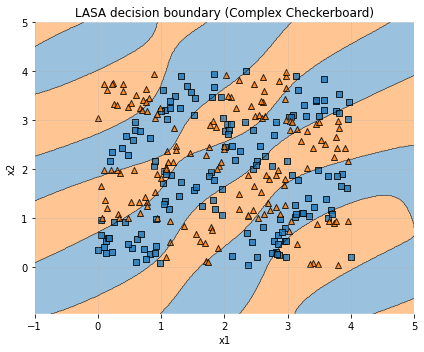

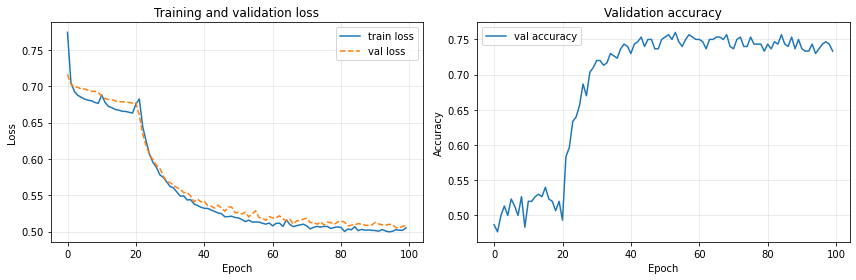

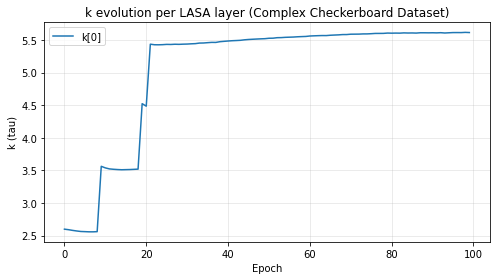

In [7]:
X, y = make_complex_checkerboard(n_samples=1500, grid_size=4, noise=0.02)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Dataset: total={len(X)} | train={len(X_train)} | test={len(X_test)}")
print(f"Class counts: 0 -> {np.sum(y==0)}  | 1 -> {np.sum(y==1)}")

# 2. Build LASA model
hidden_units = [16]
model = create_lasa_model(
    hidden_units=hidden_units,
    initial_frequency=2.6,
    theta_degrees=45.0,
    lambda_window=3e-4,
    penalty_mode='hinge',
    hybrid_alpha=0.1,
    enforce_gain_cap=False,
    gain_cap=1.25
)

# 3. Train with LASATrainer
trainer = LASATrainer(
    model,
    lr_main=1e-3, lr_tau=1e-2,
    clipnorm_main=1.0, clipnorm_tau=0.5,
    penalty_warmup_epochs=8,
    acc_eps=2.5e-3, loss_eps=1e-4,
    reverse_tau_grads=True, revert_rho_to_snapshot=True,
    shrink_tau_lr=True, tau_lr_decay=0.5, min_tau_lr=1e-5,
    shrink_penalty=True, penalty_decay=0.8, min_penalty_scale=0.05,
    stagnation_window=10, improve_threshold=0.05,
    bump_delta_k=1.0, min_epochs_between_bumps=10,
    acc_drop_threshold=0.02
)

history = trainer.train(
    X_train, y_train,
    X_test,  y_test,
    epochs=100, batch_size=32, verbose=True
)

# 4. Final evaluation
preds = model(tf.constant(X_test, tf.float32))
y_pred = (preds.numpy() > 0.5).astype(int).flatten()
final_acc = float(np.mean(y_pred == y_test))
print(f"\nFinal LASA accuracy on test set: {final_acc:.4f}")

# 5. Plots: decision boundary, training curves, k evolution
plot_lasa_decision_boundary(model, X_test, y_test)
plot_lasa_training_curves(history)
plot_k_evolution(history, title_suffix="Complex Checkerboard Dataset")
